# Comparação de Tokenizadores

Neste notebook, realizamos uma análise comparativa entre diferentes tokenizadores de modelos de linguagem para o português. Os principais pontos analisados são:

1. **Presença de Caracteres Estrangeiros:** Quantidade de tokens no vocabulário que contêm caracteres não comuns na língua portuguesa (focando no modelo BERTimbau).
2. **Eficiência de Tokenização:** Avaliação da quantidade de subtokens gerados a partir dos textos do dataset ASSIN 2 pelos seguintes modelos:
    - **mBERT** (`bert-base-multilingual-cased`)
    - **BERTimbau** (`neuralmind/bert-base-portuguese-cased`)
    - **BERTugues** (`ricardoz/BERTugues-base-portuguese-cased`)

O objetivo é demonstrar a eficiência do tokenizador do **BERTugues** em representar textos em português com menos subtokens fragmentados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re
from tqdm import tqdm
tqdm.pandas()

from datasets import Dataset, load_dataset
from transformers import AutoTokenizer

tokenizer_bert = AutoTokenizer.from_pretrained('bert-base-multilingual-cased', do_lower_case=False)
tokenizer_timbau = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased', do_lower_case=False)
tokenizer = AutoTokenizer.from_pretrained('ricardoz/BERTugues-base-portuguese-cased', do_lower_case=False)

## 1. Contagem de Caracteres Não Comuns no Português

Vamos verificar a quantidade de tokens no vocabulário do BERTimbau que contêm caracteres de blocos Unicode não habituais para textos em português (ex: caracteres asiáticos).

In [2]:
regex_find = re.compile("[^"
    u"\U00000000-\U000000FF"
    u"\U00002000-\U0000206F"
    u"\U0001F446-\U0001F450"
    u"\U0001F600-\U0001F64F"
    "]+", re.UNICODE)

# https://symbl.cc/en/unicode/blocks/

vocab_bau = [x for x in tokenizer_timbau.get_vocab().keys() if bool(regex_find.search(x))]


print(f'Quantidade de tokens com caracteres estranhos: {len(vocab_bau)}')
print(f'Exemplos: {vocab_bau[:10]}')

Quantidade de tokens com caracteres estranhos: 7438
Exemplos: ['##쬥', '##뼷', '##藍', '##环', '##쿟', '##떝', '##첥', '##红', '##ś', '##壽']


## 2. Comparação da Eficiência de Tokenização

Utilizaremos o dataset **ASSIN 2** para comparar quantos subtokens são gerados por cada tokenizador. Uma tokenização mais eficiente resulta em menos fragmentação das palavras (menos subtokens iniciados com `##`).

In [3]:
dataset = load_dataset("assin2")

def trat(x):
    return {"frase":x["premise"] + " " + x["hypothesis"]}

dataset = dataset.map(trat)


frases = []

for k in dataset.keys():
    frases.extend(dataset[k]['frase'])


df = pd.DataFrame(frases, columns = ["frase"])

In [4]:
tokenizers = {
    "timbau": tokenizer_timbau,
    "bert": tokenizer_bert,
    "gues": tokenizer
}

def aplicar_estatisticas_tokenizador(df, prefixo, tokenizador):
    """
    Aplica a tokenização, calcula a quantidade de tokens gerados e os subtokens de continuação (##)
    """
    df[f"tokens_{prefixo}"] = df.frase.progress_apply(tokenizador.tokenize)
    df[f"len_tokens_{prefixo}"] = df[f"tokens_{prefixo}"].progress_apply(len)
    df[f"len_nao_inicio_{prefixo}"] = df[f"tokens_{prefixo}"].progress_apply(
        lambda x: len([a for a in x if a.startswith("##")])
    )
    df[f"len_nao_inicio_{prefixo}_trunk"] = df[f"len_nao_inicio_{prefixo}"].progress_apply(
        lambda x: np.minimum(x, 15)
    )
    return df

for prefixo, tok in tokenizers.items():
    df = aplicar_estatisticas_tokenizador(df, prefixo, tok)

100%|██████████| 9448/9448 [00:00<00:00, 575149.26it/s]


## 3. Resultados da Comparação

Abaixo, visualizamos a distribuição da quantidade de subtokens de continuação (iniciados por `##`) gerados por cada modelo. Valores menores indicam que o tokenizador conseguiu representar as palavras de forma mais íntegra, sem precisar fragmentá-las excessivamente.

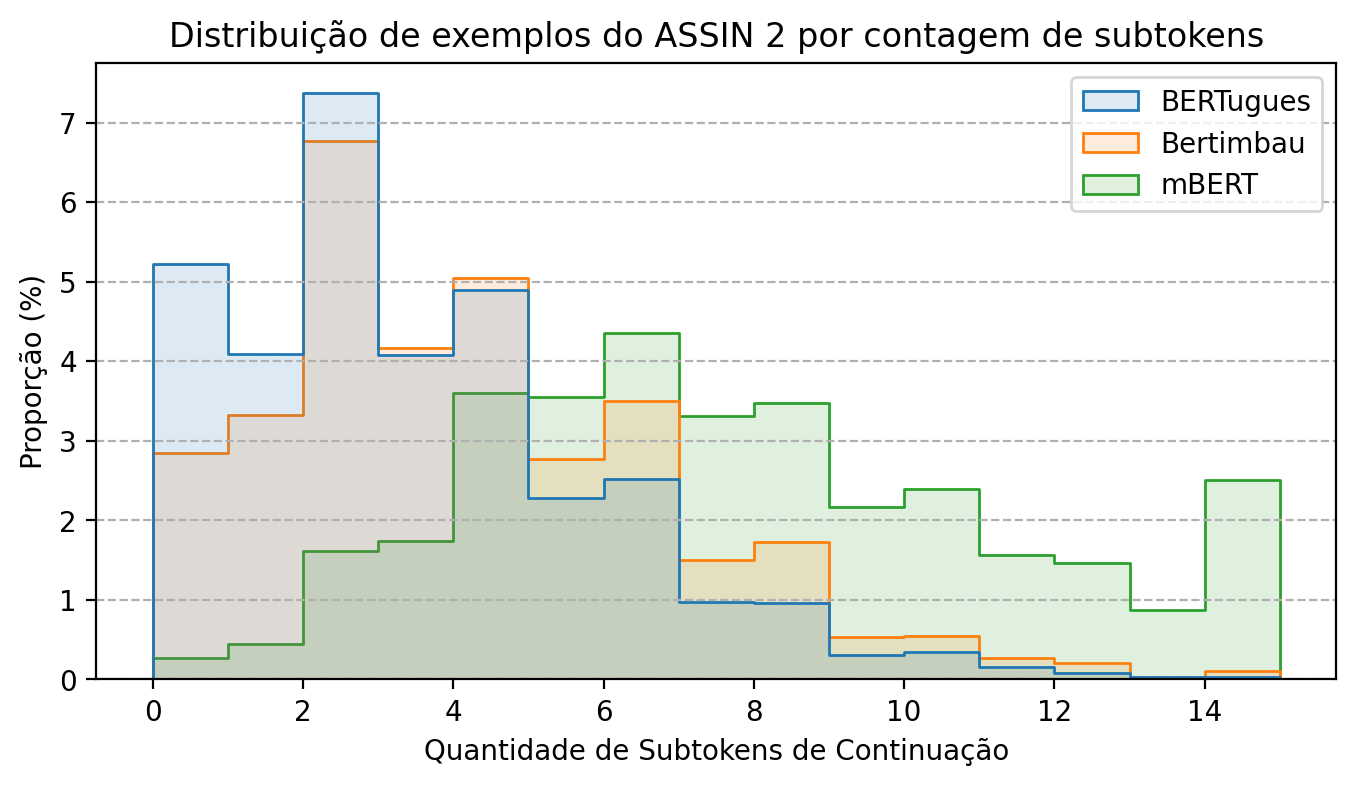

In [5]:
plt.figure(figsize=(8,4), dpi = 200)
sns.histplot(data=df[["len_nao_inicio_gues_trunk",
                      "len_nao_inicio_timbau_trunk",
                      "len_nao_inicio_bert_trunk"]].rename(columns={
"len_nao_inicio_gues_trunk":"BERTugues",
"len_nao_inicio_timbau_trunk":"Bertimbau",
"len_nao_inicio_bert_trunk":"mBERT"
}),
             stat="percent", binwidth=1, element="step", alpha = 0.15).set(
                title = "Distribuição de exemplos do ASSIN 2 por contagem de subtokens")

plt.xlabel('Quantidade de Subtokens de Continuação')
plt.ylabel('Proporção (%)')
ax = plt.gca()
ax.grid(which='major', axis='y', linestyle='--')
plt.show()

In [6]:
print(f"""Caracteres não inicio no:
mBERT: {df["len_nao_inicio_bert"].mean()}
Bertimbau: {df["len_nao_inicio_timbau"].mean()}
BERTugues: {df["len_nao_inicio_gues"].mean()}
""")

Caracteres não inicio no:
mBERT: 7.44612616426757
Bertimbau: 3.7923370025402203
BERTugues: 3.0407493649449617

